# 10 · LGWR / GWR

Template para el modelo geoestadístico local. En el repo actual la implementación disponible es `GWRModel`, así que este notebook queda preparado para usar ese wrapper y analizar coeficientes locales.

## Hipótesis del modelo

- La relación entre features y `precio_m2` cambia según la localización.
- El modelo debería capturar heterogeneidad espacial mejor que una regresión global.
- La interpretabilidad principal viene por mapas de coeficientes locales y diagnóstico de residuos.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import geopandas as gpd
import seaborn as sns


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.gwrmodel import GWRModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import *

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "10_lgwr"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Datos y configuración

In [ ]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_caba_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_caba_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_caba_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)

target_col = "log_precio"
coord_cols = ["longitud", "latitud"]
feature_cols = [
    "area_m2_total",
    "area_m2_descubierta",
    "ambientes",
    "antiguedad",
    "expensas",
    "estado_num",
]


In [ ]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

## Entrenamiento

In [ ]:
gwr_params = {
    "kernel": "bisquare",
    "fixed": False,
}

model = GWRModel(gwr_params=gwr_params)
model.fit(X_train, y_train, coords_train)
model


Model type                                                         Gaussian
Number of observations:                                                7430
Number of covariates:                                                     7

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           2344.639
Log-likelihood:                                                   -6257.854
AIC:                                                              12529.707
AICc:                                                             12531.727
BIC:                                                             -63818.646
R2:                                                                   0.458
Adj. R2:                                                              0.458

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

## Tuning

Podés barrer `kernel`, `fixed`, `bw` y distintas definiciones de features. Si hacés tuning, dejá el criterio registrado en `run_config.json`.

In [ ]:
model.tune_hyperparameters(X_test, y_test.values.reshape(-1, 1), coords_test)
best_config = {"gwr_params": gwr_params, "selected_bw": getattr(model, "bw_", None)}
best_config


/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.198474623170734e-18.
  xtx_inv_xt = linalg.solve(xtx, xT)
/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.602791449630336e-18.
  xtx_inv_xt = linalg.solve(xtx, xT)
/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.5728898915642586e-18.
  xtx_inv_xt = linalg.solve(xtx, xT)
/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.8668606926228197e-17.
  xtx_inv_xt = linalg.solve(xtx, xT

LinAlgError: A singular matrix detected: slice(s) [0] are singular.

## Evaluación global

In [ ]:
y_pred_log = model.predict(
    X_val,
    coords_val
)

# revertir log
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_val)

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics

{'rmse': 1.7529728823070836,
 'mae': 0.3562715369552486,
 'r2': -4.632249999798838,
 'bias': -0.02964969533203601,
 'median_abs_error': 0.2349680737202835,
 'mape': 2.938104719514497}

## Diagnóstico espacial

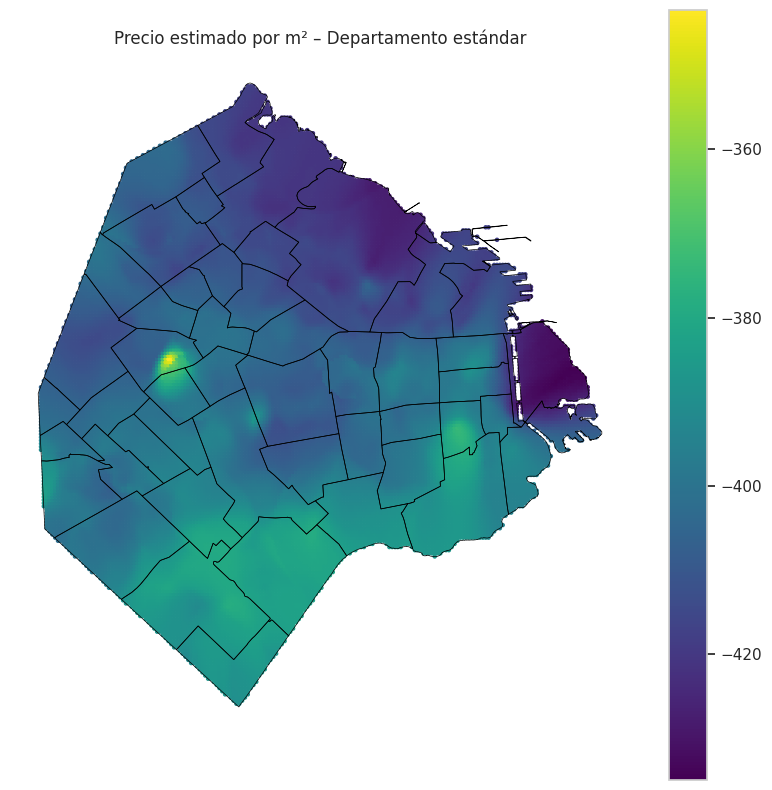

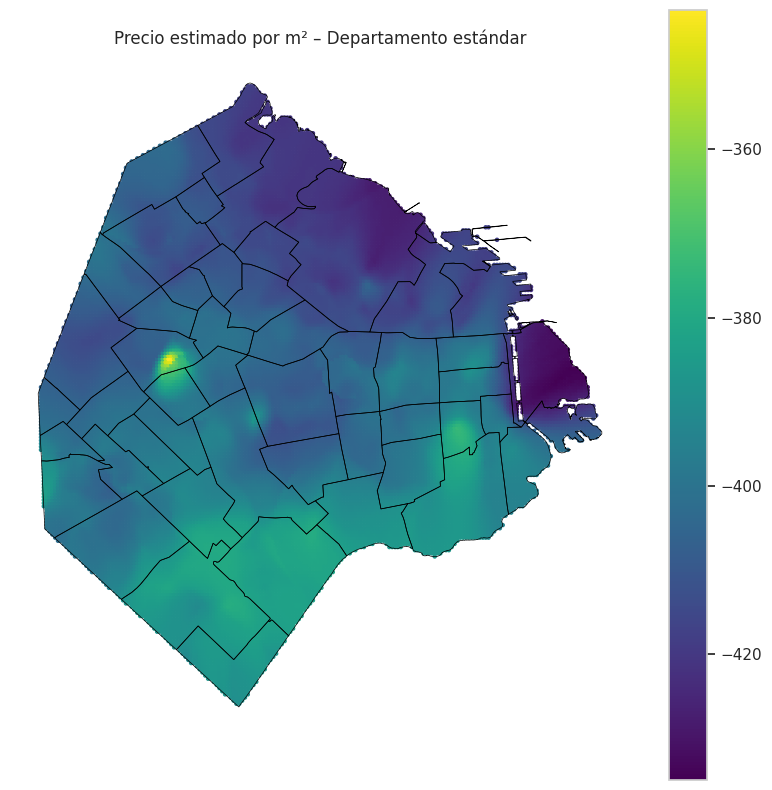

In [ ]:
barrios_path = PROJECT_ROOT / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

#mapa.save("mapa_modelo_lgwr.png")

#mapa.save("mapa_modelo_lgwr.pdf")



## Interpretación

En GWR la interpretación más útil no suele ser una `feature importance` global, sino:

- coeficientes locales
- estabilidad espacial de cada feature
- signos dominantes por zona
- residuos espacialmente agrupados

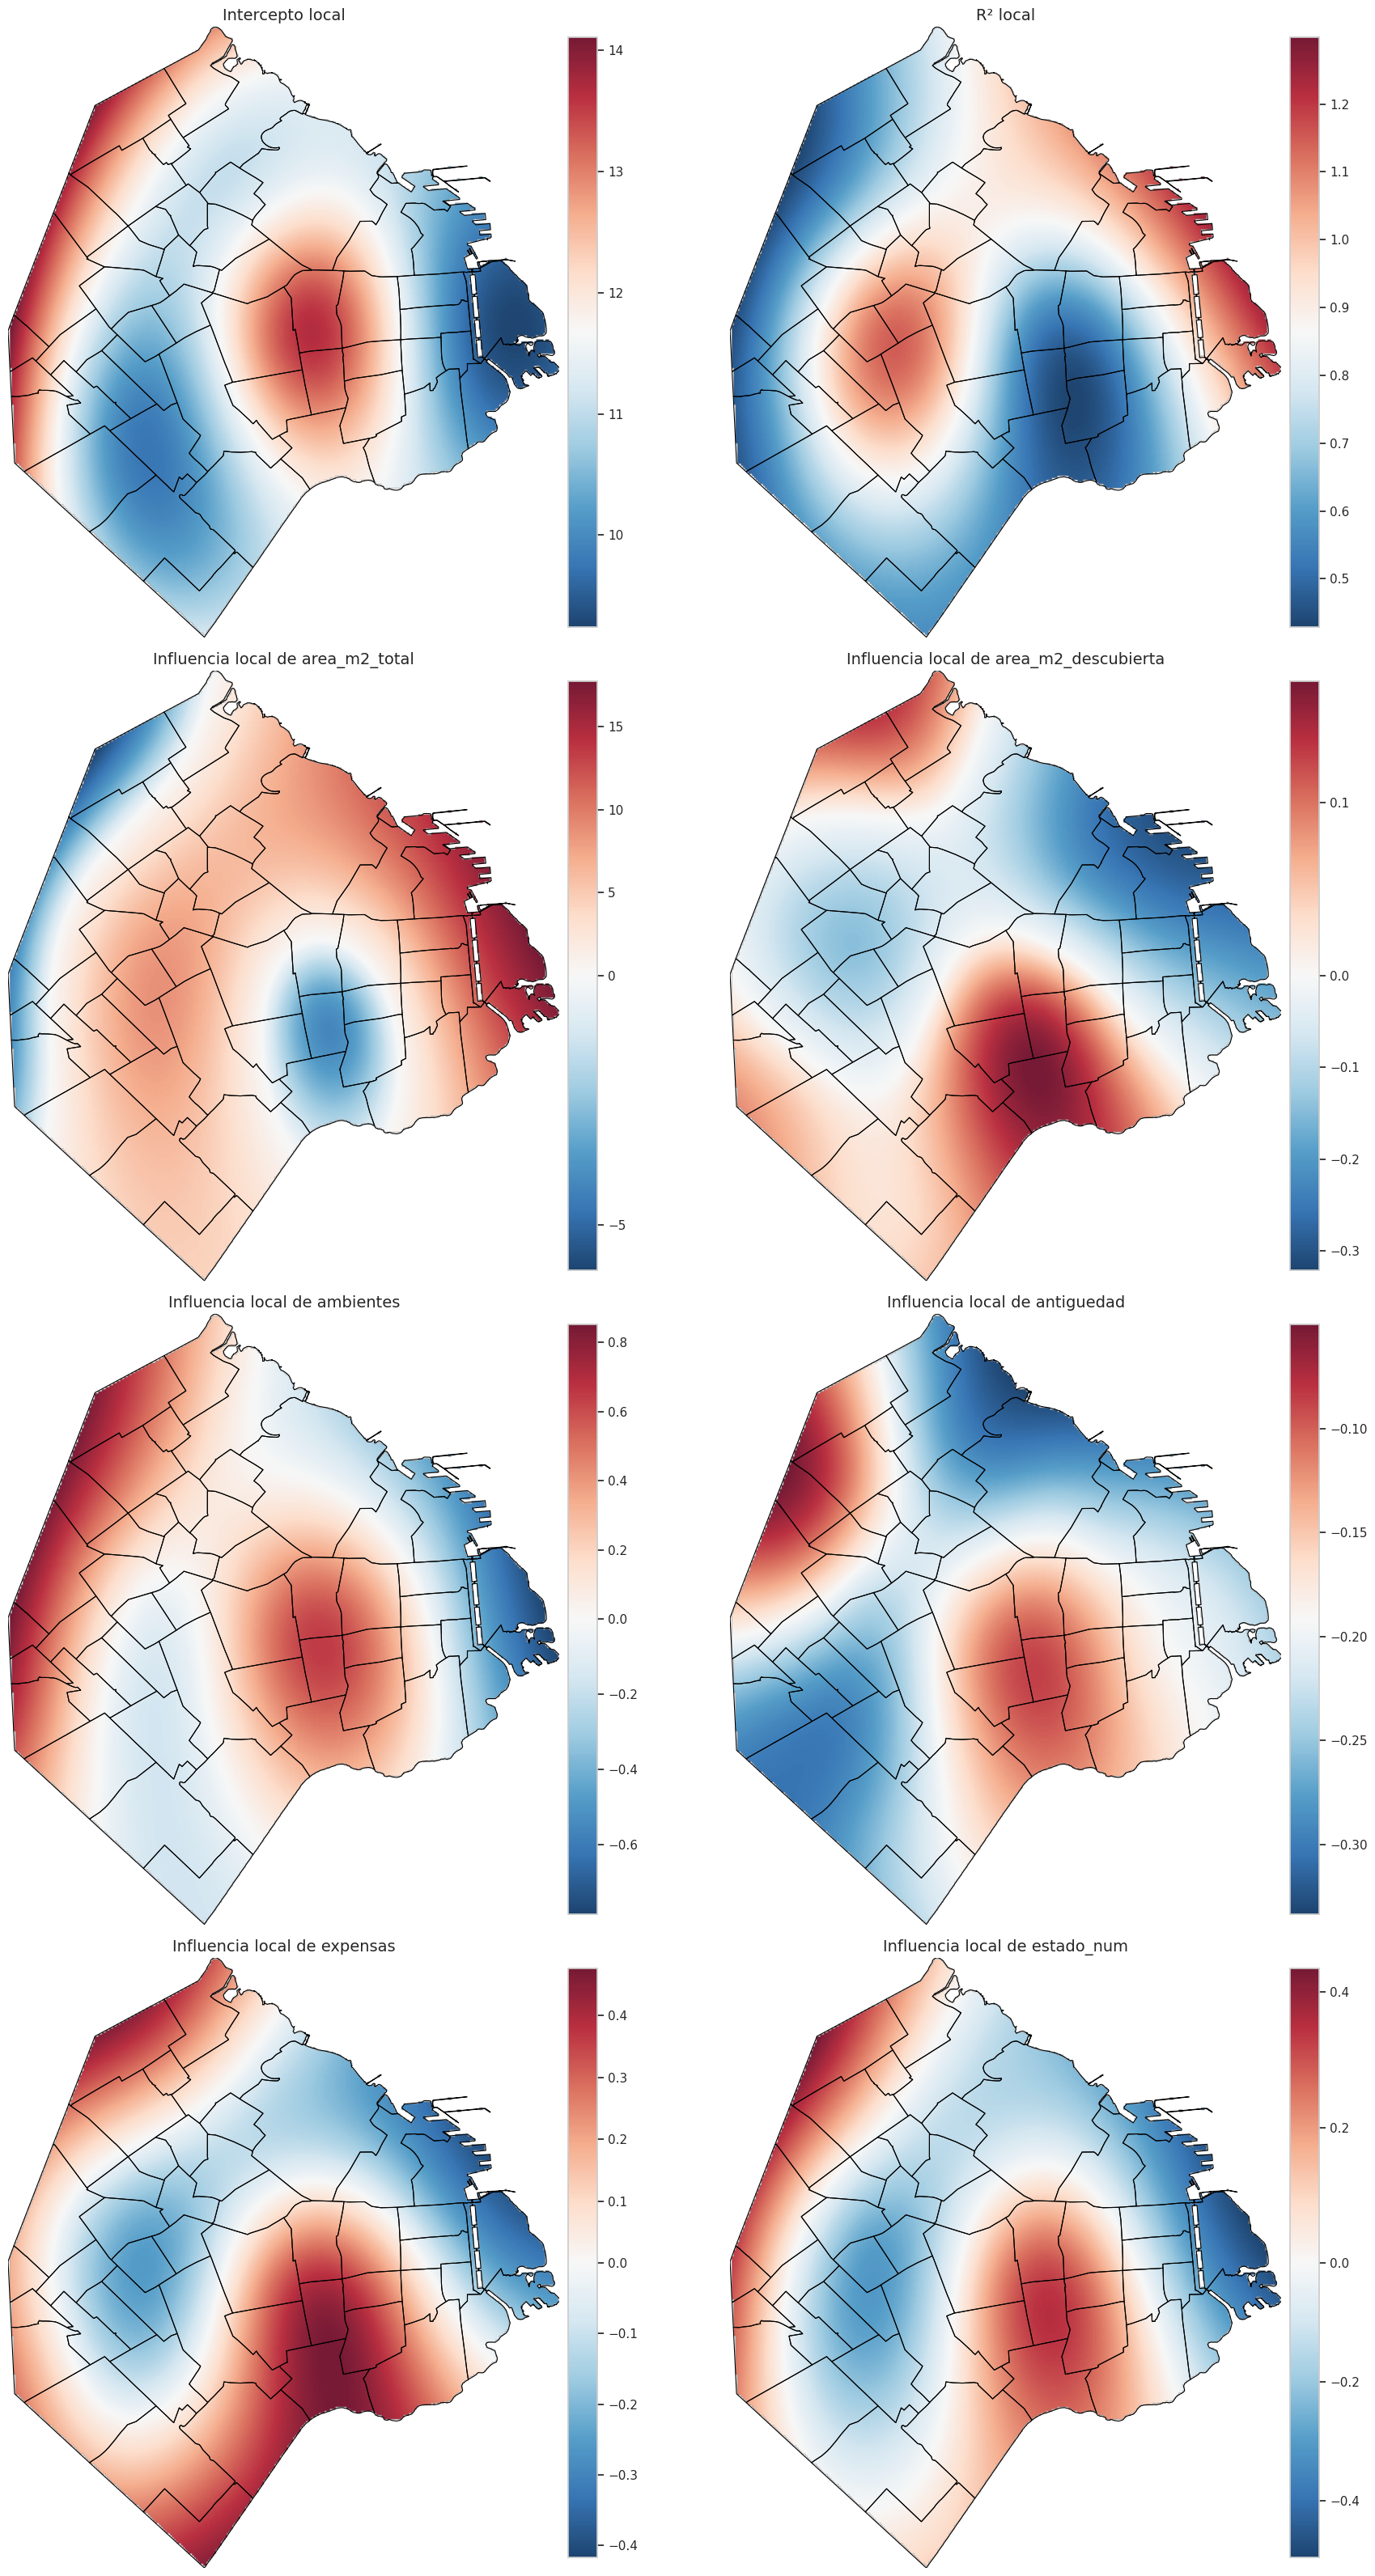

In [ ]:
barrios = gpd.read_file(barrios_path)
barrios = barrios.to_crs(gdf_train.crs)
surfaces = model.plot_gwr_surfaces(
    gdf=gdf_train,
    feature_names= feature_cols,
    barrios = barrios.to_crs(gdf_train.crs),
    grid_size=300,
    return_surfaces=True
)


## Export de artefactos

In [ ]:
# test_export = gdf_test[[target_col] + coord_cols].copy()
# test_export = test_export.rename(columns={target_col: "y_true"})
# test_export["y_pred"] = np.asarray(y_pred).reshape(-1)
# test_export["residual"] = test_export["y_true"] - test_export["y_pred"]
# test_export["split"] = "test"
# test_export.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=False)
# local_betas.to_parquet(OUTPUT_DIR / "interpretability.parquet", index=False)
# (OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False))
# (OUTPUT_DIR / "run_config.json").write_text(json.dumps(best_config, indent=2, ensure_ascii=False))